# Library Type Causal Analysis


In [8]:
import warnings
import re
import sys
from pathlib import Path

import graphviz
import numpy as np
import pandas as pd
from dowhy import CausalModel
from IPython.display import display
from sklearn.exceptions import DataConversionWarning
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore", category=DataConversionWarning)


def find_repo_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "utils" / "statistical_tests.py").exists():
            return candidate
    raise RuntimeError("Could not find repo root containing utils/statistical_tests.py")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils import statistical_tests as tests


In [9]:
INPUT_FILE = "alerts_with_lib_category_and_apk_size_codeql.csv"


def normalize_verdict(value):
    normalized = str(value).strip().lower()
    if normalized in {"1", "true"}:
        return 1
    if normalized in {"0", "false"}:
        return 0
    raise ValueError(f"Unsupported verdict value: {value!r}")


def normalize_rule_id(value):
    if pd.isna(value):
        return "missing"
    value = str(value).strip()
    if not value:
        return "missing"
    return re.sub(r"[^0-9A-Za-z_]+", "_", value)


def add_rule_id_columns(data):
    rule_id_dummies = pd.get_dummies(data["rule_id"], prefix="rule_id", drop_first=True, dtype=int)
    return pd.concat([data, rule_id_dummies], axis=1), list(rule_id_dummies.columns)


df = pd.read_csv(INPUT_FILE)
print("Original rows:", len(df))

df = df[~df["code_location"].str.contains("obfuscated", case=False, na=False)].copy()
print("After removing obfuscated:", len(df))

df["verdict"] = df["verdict"].apply(normalize_verdict)
df["is_3rd_party"] = (~df["code_location"].isin(["developer_written"])).astype(int)
df["is_third_party"] = df["is_3rd_party"]

rule_id_source_column = "rule_id" if "rule_id" in df.columns else "ruleId"
df["rule_id"] = df[rule_id_source_column].apply(normalize_rule_id)

popularity_column = "app_popularity" if "app_popularity" in df.columns else "apk_category"
category_order = [
    "<100", "100-500", "500-1k", "1k-5k", "5k-10k", "10k-50k",
    "50k-100k", "100k-500k", "500k-1M", "1M-5M", ">5M",
]
ord_map = {category: index for index, category in enumerate(category_order)}
df["app_popularity_encoded"] = df[popularity_column].map(ord_map)
df = df.dropna(subset=["app_popularity_encoded", "apk_size"]).copy()
df["app_popularity_encoded"] = df["app_popularity_encoded"].astype(int)

scaler = RobustScaler()
df["apk_size_scaled"] = scaler.fit_transform(df[["apk_size"]])

df, rule_id = add_rule_id_columns(df)

print("Popularity column:", popularity_column)
print("Rule ID columns:", len(rule_id))
print(rule_id[:20])


Original rows: 21501
After removing obfuscated: 21501
Popularity column: apk_category
Rule ID columns: 16
['rule_id_java_disabled_certificate_revocation_checking', 'rule_id_java_hash_without_salt', 'rule_id_java_improper_webview_certificate_validation', 'rule_id_java_insecure_basic_auth', 'rule_id_java_insecure_randomness', 'rule_id_java_insecure_smtp_ssl', 'rule_id_java_insecure_trustmanager', 'rule_id_java_insufficient_key_size', 'rule_id_java_potentially_weak_cryptographic_algorithm', 'rule_id_java_predictable_seed', 'rule_id_java_rsa_without_oaep', 'rule_id_java_static_initialization_vector', 'rule_id_java_unsafe_cert_trust', 'rule_id_java_unsafe_hostname_verification', 'rule_id_java_unsafe_tls_version', 'rule_id_java_weak_cryptographic_algorithm']


In [10]:
small_libs = ["SocialMedia", "Analytics", "Cloud"]
df["lib_grouped"] = df["code_location"].replace(small_libs, "Small_Libraries")
df.loc[df["lib_grouped"] == "developer_written", "lib_grouped"] = "App_Source_Code"
df.loc[df["lib_grouped"] == "others", "lib_grouped"] = "miscellaneous"

print("\nGrouped library counts:")
print(df["lib_grouped"].value_counts())

baseline_name = "App_Source_Code"
libs = [baseline_name] + [lib for lib in df["lib_grouped"].unique() if lib != baseline_name]
print("\nLibrary levels:")
for lib in libs:
    print("-", lib)



Grouped library counts:
lib_grouped
Android            9345
miscellaneous      6367
Utilities          4522
Small_Libraries     713
App_Source_Code     554
Name: count, dtype: int64

Library levels:
- App_Source_Code
- Android
- miscellaneous
- Utilities
- Small_Libraries


In [11]:
def make_pairwise_balanced(df_in, lib_name, baseline="App_Source_Code", random_state=100):
    df_sub = df_in[df_in["lib_grouped"].isin([baseline, lib_name])].copy()
    baseline_df = df_sub[df_sub["lib_grouped"] == baseline]
    lib_df = df_sub[df_sub["lib_grouped"] == lib_name]
    target_count = len(baseline_df)

    if target_count == 0:
        raise ValueError("No App_Source_Code rows found for the baseline group.")
    if len(lib_df) == 0:
        raise ValueError(f"No rows found for library group: {lib_name}")

    if len(lib_df) >= target_count:
        lib_balanced = lib_df.sample(n=target_count, replace=False, random_state=random_state)
    else:
        lib_balanced = lib_df.sample(n=target_count, replace=True, random_state=random_state)

    df_balanced = pd.concat([baseline_df.copy(), lib_balanced], axis=0)
    return df_balanced.sample(frac=1, random_state=random_state).reset_index(drop=True)


def print_refutation(method, ref):
    print(f"\nRefuter: {method}")
    if isinstance(ref, list):
        for item in ref:
            print(item)
    else:
        print(ref)


def get_refutation_value(ref, attribute):
    if isinstance(ref, list):
        return [getattr(item, attribute, None) for item in ref]
    return getattr(ref, attribute, None)


def apply_refutation_tests(lib_name, label, model, identified_estimand, estimate, ate):
    ref_rows = []
    refutation_methods = [
        "random_common_cause",
        "placebo_treatment_refuter",
        "data_subset_refuter",
        "dummy_outcome_refuter",
    ]

    for method in refutation_methods:
        if method == "placebo_treatment_refuter":
            ref = model.refute_estimate(
                identified_estimand,
                estimate,
                method_name=method,
                placebo_type="permute",
                num_simulations=200,
            )
        elif method == "data_subset_refuter":
            ref = model.refute_estimate(
                identified_estimand,
                estimate,
                method_name=method,
                subset_fraction=0.8,
                num_simulations=200,
            )
        elif method == "dummy_outcome_refuter":
            ref = model.refute_estimate(
                identified_estimand,
                estimate,
                method_name=method,
                num_simulations=200,
            )
        else:
            ref = model.refute_estimate(identified_estimand, estimate, method_name=method)

        print_refutation(method, ref)
        ref_rows.append({
            "library": lib_name,
            "setting": label,
            "refuter": method,
            "orig_effect": ate,
            "new_effect": get_refutation_value(ref, "new_effect"),
            "p_value": get_refutation_value(ref, "p_value"),
        })
    return ref_rows


In [12]:
def run_library_contrast(df_sub, lib_name, baseline="App_Source_Code", label="balanced"):
    df_sub = df_sub.copy()
    df_sub["treatment_lib"] = (df_sub["lib_grouped"] == lib_name).astype(int)

    print("\n" + "-" * 14 + f" {lib_name} vs {baseline} " + "-" * 14)

    # Combined approach: treated rows are baseline + selected library; control rows are baseline only.
    df_all = df_sub.copy()
    df_all["combined"] = 1
    df_baseline = df_sub[df_sub["treatment_lib"] == 0].copy()
    df_baseline["combined"] = 0
    df_sub = pd.concat([df_all, df_baseline], ignore_index=True)

    tests.correlation_test_treatment_to_outcome(df_sub)
    print(df_sub["combined"].value_counts())
    n0 = int((df_sub["combined"] == 0).sum())
    n1 = int((df_sub["combined"] == 1).sum())

    common_causes = ["is_3rd_party", "app_popularity_encoded"]

    causal_graph = """
    digraph {
        is_3rd_party -> combined;
        app_popularity_encoded -> combined;
        combined -> verdict;
        app_popularity_encoded -> verdict;
    }
    """

    display(graphviz.Source(causal_graph))

    model = CausalModel(
        data=df_sub,
        treatment="combined",
        outcome="verdict",
        graph=causal_graph.replace("\n", " "),
        common_causes=common_causes,
    )

    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.propensity_score_matching",
        target_units="ate",
        confidence_intervals="bootstrap",
        method_params={
            "num_simulations": 300,
            "sample_size_fraction": 1.0,
            "confidence_level": 0.95,
        },
    )

    ate = float(estimate.value)
    try:
        ci_low, ci_high = estimate.get_confidence_intervals()
        ci_low, ci_high = float(ci_low), float(ci_high)
    except Exception:
        ci_low, ci_high = None, None

    print("ATE:", ate)
    if ci_low is not None:
        print("95% CI:", (ci_low, ci_high))

    ref_rows = apply_refutation_tests(lib_name, label, model, identified_estimand, estimate, ate)

    result_row = {
        "library": lib_name,
        "setting": label,
        "n_baseline": n0,
        "n_treatment": n1,
        "common_causes": ", ".join(common_causes),
        "ATE": ate,
        "CI_low": ci_low,
        "CI_high": ci_high,
    }
    return result_row, ref_rows



-------------- Android vs App_Source_Code --------------

combined -> verdict (Spearman)
rho = -0.0133, p = 0.5879

combined
1    1108
0     554
Name: count, dtype: int64


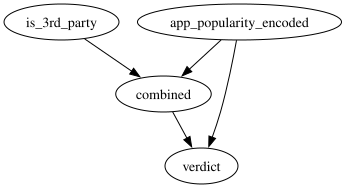

ATE: -0.02045728038507822
95% CI: (-0.17930204572803848, 0.056558363417569195)

Refuter: random_common_cause
Refute: Add a random common cause
Estimated effect:-0.02045728038507822
New effect:-0.020457280385078217
p value:1.0


Refuter: placebo_treatment_refuter
Refute: Use a Placebo Treatment
Estimated effect:-0.02045728038507822
New effect:0.010676895306859207
p value:0.82


Refuter: data_subset_refuter
Refute: Use a subset of data
Estimated effect:-0.02045728038507822
New effect:-0.008545112781954887
p value:0.81


Refuter: dummy_outcome_refuter
Refute: Use a Dummy Outcome
Estimated effect:0
New effect:0.006672911612086691
p value:0.98


-------------- miscellaneous vs App_Source_Code --------------

combined -> verdict (Spearman)
rho = -0.1239, p = 0.0000

combined
1    1108
0     554
Name: count, dtype: int64


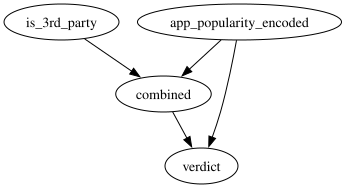

ATE: -0.11853188929001203
95% CI: (-0.3297232250300842, -0.04933814681107099)

Refuter: random_common_cause
Refute: Add a random common cause
Estimated effect:-0.11853188929001203
New effect:-0.118531889290012
p value:1.0


Refuter: placebo_treatment_refuter
Refute: Use a Placebo Treatment
Estimated effect:-0.11853188929001203
New effect:0.0061552346570397124
p value:0.97


Refuter: data_subset_refuter
Refute: Use a subset of data
Estimated effect:-0.11853188929001203
New effect:-0.07625939849624061
p value:0.55


Refuter: dummy_outcome_refuter
Refute: Use a Dummy Outcome
Estimated effect:0
New effect:0.0013188504446624994
p value:0.98


-------------- Utilities vs App_Source_Code --------------

combined -> verdict (Spearman)
rho = -0.0451, p = 0.0662

combined
1    1108
0     554
Name: count, dtype: int64


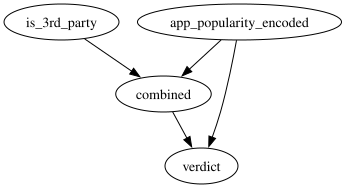

ATE: -0.06799037304452467
95% CI: (-0.24007220216606495, -0.01564380264741276)

Refuter: random_common_cause
Refute: Add a random common cause
Estimated effect:-0.06799037304452467
New effect:-0.0679903730445247
p value:1.0


Refuter: placebo_treatment_refuter
Refute: Use a Placebo Treatment
Estimated effect:-0.06799037304452467
New effect:0.0017930204572803854
p value:0.9


Refuter: data_subset_refuter
Refute: Use a subset of data
Estimated effect:-0.06799037304452467
New effect:-0.020533834586466168
p value:0.33000000000000007


Refuter: dummy_outcome_refuter
Refute: Use a Dummy Outcome
Estimated effect:0
New effect:0.02016259017567677
p value:0.8999999999999999


-------------- Small_Libraries vs App_Source_Code --------------

combined -> verdict (Spearman)
rho = 0.0020, p = 0.9355

combined
1    1108
0     554
Name: count, dtype: int64


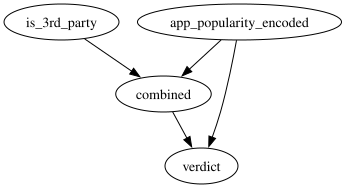

ATE: -0.052346570397111915
95% CI: (-0.2009626955475331, -0.031889290012033694)

Refuter: random_common_cause
Refute: Add a random common cause
Estimated effect:-0.052346570397111915
New effect:-0.05234657039711191
p value:1.0


Refuter: placebo_treatment_refuter
Refute: Use a Placebo Treatment
Estimated effect:-0.052346570397111915
New effect:0.002942238267148014
p value:0.73


Refuter: data_subset_refuter
Refute: Use a subset of data
Estimated effect:-0.052346570397111915
New effect:0.003616541353383459
p value:0.17999999999999994


Refuter: dummy_outcome_refuter
Refute: Use a Dummy Outcome
Estimated effect:0
New effect:0.008329036227374305
p value:0.8899999999999999



In [13]:
main_rows = []
ref_rows_all = []

for lib in libs:
    if lib == baseline_name:
        continue

    df_balanced = make_pairwise_balanced(df, lib, baseline=baseline_name, random_state=100)
    main_row, ref_rows = run_library_contrast(df_balanced, lib, baseline=baseline_name, label="balanced")
    main_rows.append(main_row)
    ref_rows_all.extend(ref_rows)


In [14]:
main_df = pd.DataFrame(main_rows).sort_values(["library", "setting"])
ref_df = pd.DataFrame(ref_rows_all)

print("\n\n" + "-" * 25 + " Detailed (ATEs) " + "-" * 25)
print(main_df[["library", "setting", "n_baseline", "n_treatment", "common_causes", "ATE", "CI_low", "CI_high"]])

pivot = main_df.pivot(index="library", columns="setting", values="ATE")
print("\n\n" + "-" * 25 + " Summary ATE " + "-" * 25)
print(pivot)




------------------------- Detailed (ATEs) -------------------------
           library   setting  n_baseline  n_treatment  \
0          Android  balanced         554         1108   
3  Small_Libraries  balanced         554         1108   
2        Utilities  balanced         554         1108   
1    miscellaneous  balanced         554         1108   

                          common_causes       ATE    CI_low   CI_high  
0  is_3rd_party, app_popularity_encoded -0.020457 -0.179302  0.056558  
3  is_3rd_party, app_popularity_encoded -0.052347 -0.200963 -0.031889  
2  is_3rd_party, app_popularity_encoded -0.067990 -0.240072 -0.015644  
1  is_3rd_party, app_popularity_encoded -0.118532 -0.329723 -0.049338  


------------------------- Summary ATE -------------------------
setting          balanced
library                  
Android         -0.020457
Small_Libraries -0.052347
Utilities       -0.067990
miscellaneous   -0.118532
